# Anomaly Detection su Dati Tabulari — Statlog (Shuttle)
## Corso Machine Learning — ITS Angelo Rizzoli 2026

**Dataset:** Statlog (Shuttle) — dati di sensori della navetta spaziale. 9 feature numeriche,
49.097 campioni. La classe dominante rappresenta il funzionamento **normale**; gli stati rari
rappresentano **anomalie** (~7.2%). È un benchmark standard per l'outlier detection.

**Approccio:** Unsupervised Anomaly Detection con **Autoencoder denso** addestrato sui soli
campioni normali, potenziato da un **ensemble** con Random Forest e XGBoost. Tutti i metodi sono
ancorati al programma di studio:

| Componente | Sezione del programma |
|---|---|
| Autoencoder denso, anomaly score = errore di ricostruzione L2 | Sez. 21–22 |
| Random Forest (bagging → riduce varianza) | Sez. 15 |
| XGBoost (boosting → riduce bias, early stopping) | Sez. 16 |
| Soglia ottimizzata in F1 su validation | Sez. 14 |
| Metriche F1/Precision/Recall/AUC per classi sbilanciate | Sez. 13 |
| Preprocessing anti-data leakage | Sez. 11 |
| Standardizzazione (necessaria per reti neurali) | Sez. 9 |

A differenza di dataset con feature poco informative, qui le anomalie sono **realmente
distinguibili**: l'AUC riflette la capacità del modello, non lo sbilanciamento delle classi.

## 1. Importazione delle Librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

import xgboost
print(f"PyTorch : {torch.__version__}")
print(f"XGBoost : {xgboost.__version__}")
print(f"Device  : {'cuda' if torch.cuda.is_available() else 'cpu'}")


PyTorch : 2.12.0+cu130
XGBoost : 3.2.0
Device  : cpu


## 2. Caricamento del Dataset

Il dataset Shuttle ha 9 feature numeriche continue e una colonna target binaria `anomaly`
(0 = normale, 1 = anomalia). Le feature sono già numeriche: nessun encoding categorico necessario
(a differenza di NSL-KDD), il che semplifica il preprocessing.

In [2]:
df = pd.read_csv("shuttle.csv")

print(f"Shape: {df.shape}\n")
display(df.head())

print("\nInformazioni sulle colonne:")
info = pd.DataFrame({
    "Dtype"   : df.dtypes,
    "Non-Null": df.notnull().sum(),
    "Missing" : df.isnull().sum(),
    "Min"     : df.min(),
    "Max"     : df.max(),
})
display(info)

print("\nNessun valore mancante." if df.isnull().sum().sum() == 0
      else f"Valori mancanti: {df.isnull().sum().sum()}")


Shape: (49097, 10)



,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,anomaly
0,50.0,21.0,77.0,0.0,28.0,0.0,27.0,48.0,22.0,1
1,53.0,0.0,82.0,0.0,52.0,-5.0,29.0,30.0,2.0,0
2,37.0,0.0,76.0,0.0,28.0,18.0,40.0,48.0,8.0,0
3,37.0,0.0,79.0,0.0,34.0,-26.0,43.0,46.0,2.0,0
4,85.0,0.0,88.0,-4.0,6.0,1.0,3.0,83.0,80.0,1



Informazioni sulle colonne:


,Dtype,Non-Null,Missing,Min,Max
feature_1,float64,49097,0,27.0,126.0
feature_2,float64,49097,0,-4821.0,5075.0
feature_3,float64,49097,0,21.0,149.0
feature_4,float64,49097,0,-3939.0,3830.0
feature_5,float64,49097,0,-188.0,436.0
feature_6,float64,49097,0,-26739.0,15164.0
feature_7,float64,49097,0,-48.0,105.0
feature_8,float64,49097,0,-353.0,270.0
feature_9,float64,49097,0,-356.0,266.0
anomaly,int64,49097,0,0.0,1.0



Nessun valore mancante.


## 3. Analisi Esplorativa (EDA)

Si verifica lo sbilanciamento (che impone F1/AUC al posto dell'accuracy, Sez. 13) e si osserva la
separabilità delle feature tra normali e anomali.

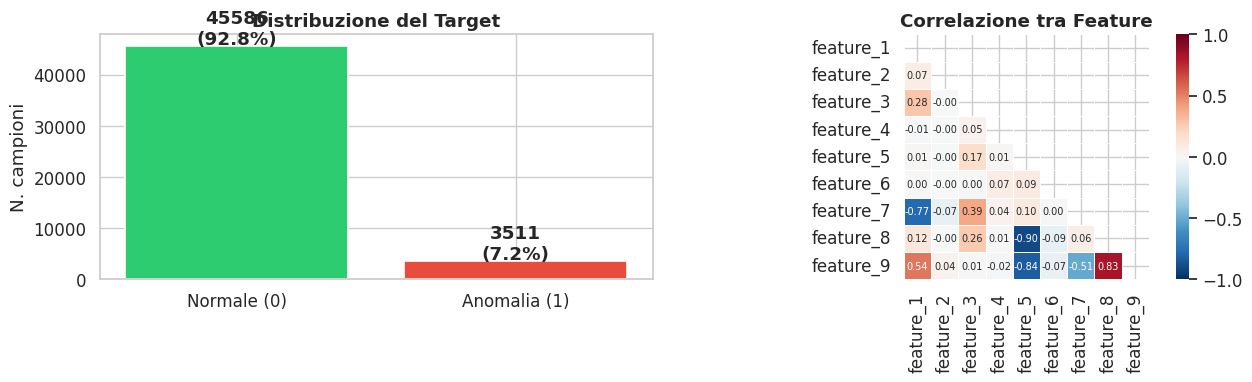

Normali (0)  : 45586 (92.8%)
Anomalie (1) : 3511 (7.2%)
Dataset sbilanciato (~7% anomalie) -> Accuracy ingannevole (Sez. 13).


In [3]:
feature_cols = [c for c in df.columns if c != "anomaly"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df["anomaly"].value_counts().sort_index()
axes[0].bar(["Normale (0)", "Anomalia (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Distribuzione del Target", fontweight="bold")
axes[0].set_ylabel("N. campioni")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 400, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")

corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, square=True, ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("Correlazione tra Feature", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_sh_eda.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Normali (0)  : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Anomalie (1) : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print("Dataset sbilanciato (~7% anomalie) -> Accuracy ingannevole (Sez. 13).")


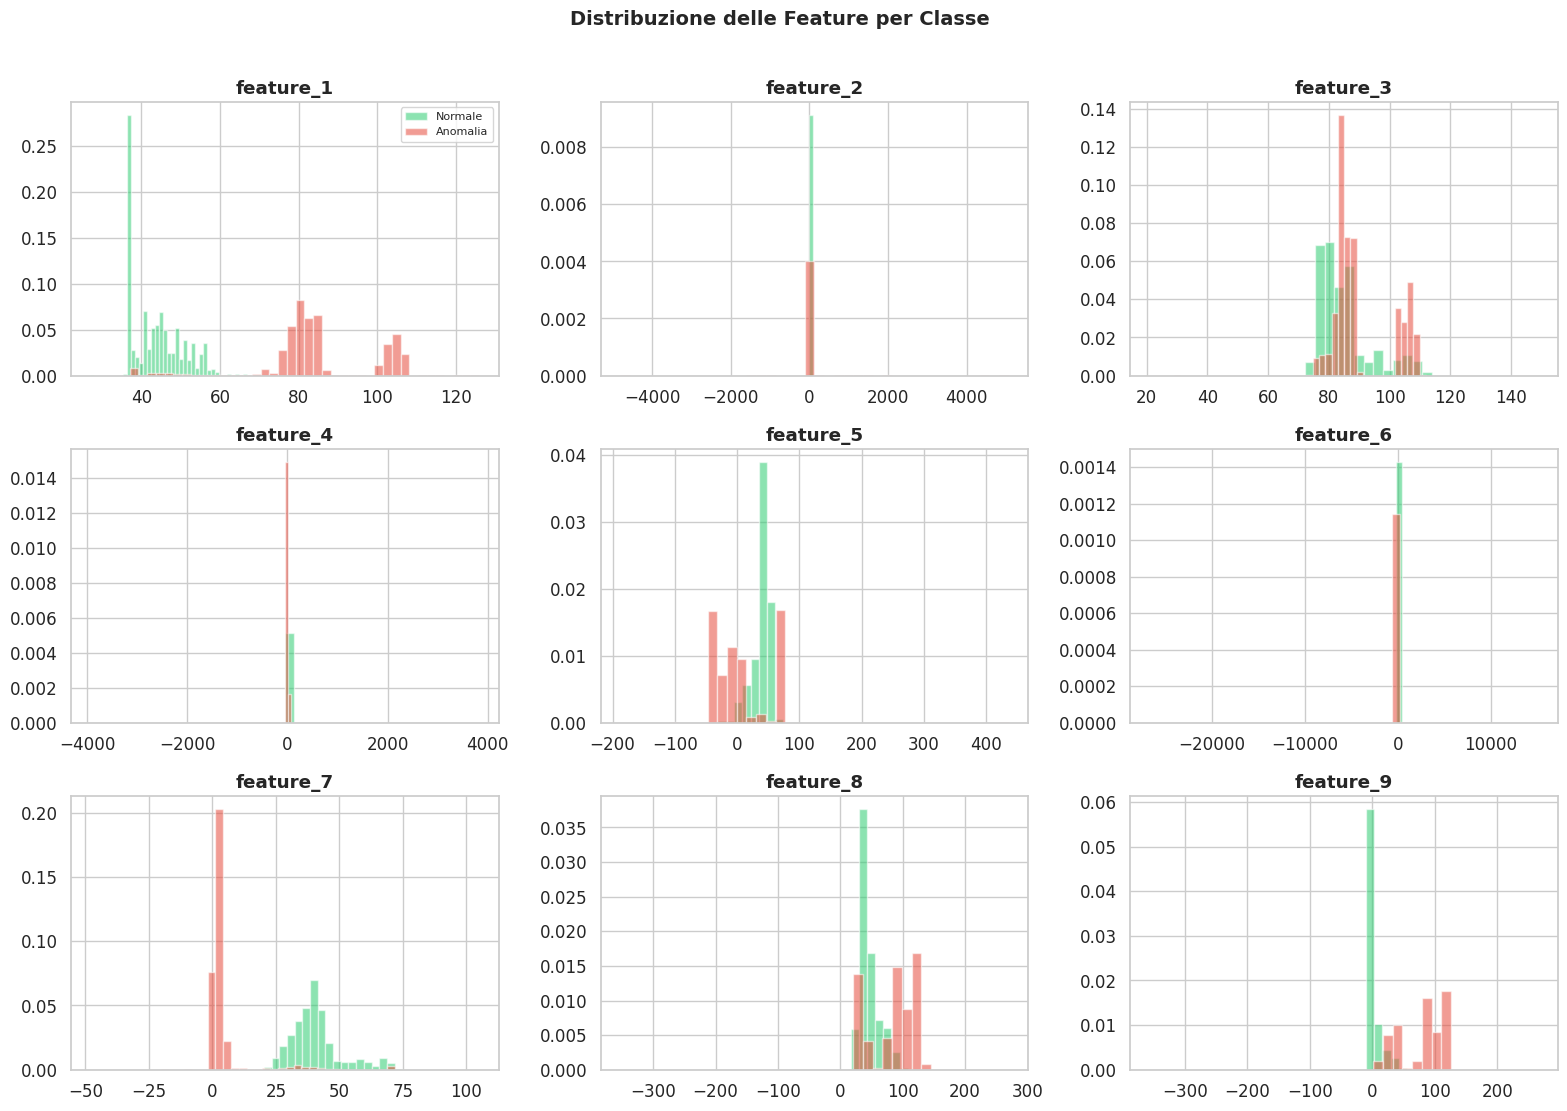

Diverse feature mostrano distribuzioni nettamente separate tra le due classi:
le anomalie sono realmente distinguibili -> ci aspettiamo AUC alto e ONESTO.


In [4]:
# Distribuzione delle feature per classe (separabilità visiva)
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    for lab, col, name in [(0, "#2ecc71", "Normale"), (1, "#e74c3c", "Anomalia")]:
        data = df[df["anomaly"] == lab][feat]
        axes[i].hist(data, bins=40, alpha=0.55, color=col, density=True, label=name)
    axes[i].set_title(feat, fontweight="bold")
    if i == 0:
        axes[i].legend(fontsize=8)
plt.suptitle("Distribuzione delle Feature per Classe", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_sh_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Diverse feature mostrano distribuzioni nettamente separate tra le due classi:")
print("le anomalie sono realmente distinguibili -> ci aspettiamo AUC alto e ONESTO.")


## 4. Preprocessing Anti-Data Leakage (Sez. 11)

**Regola d'oro (Sez. 11):** `.fit()` esclusivamente su `X_train`; `.transform()` su validation e test.

**Standardizzazione (Sez. 9):** necessaria perché l'autoencoder è una rete neurale e le feature
Shuttle hanno scale molto diverse; senza standardizzazione le feature con valori grandi
dominerebbero la loss di ricostruzione.

**Architettura dei set:** un unico split stratificato train/val/test. L'autoencoder usa i soli
normali del train; Random Forest e XGBoost usano il train etichettato completo.

In [5]:
X = df[feature_cols]
y = df["anomaly"].astype(int)          # 1 = anomalia (classe positiva, Sez. 22)

# Split stratificato 60/20/20
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval)

print(f"Train : {len(X_train):5d}  (anomalie: {y_train.sum()}, normali: {(y_train==0).sum()})")
print(f"Val   : {len(X_val):5d}  (anomalie: {y_val.sum()}, normali: {(y_val==0).sum()})")
print(f"Test  : {len(X_test):5d}  (anomalie: {y_test.sum()}, normali: {(y_test==0).sum()})")

# Standardizzazione: fit SOLO su train (Sez. 9 + Sez. 11)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print(f"\nScaler fittato su {len(X_train)} campioni di training (anti-leakage OK).")

# Soli normali per l'autoencoder (Sez. 22)
X_train_normal_sc = X_train_sc[y_train.values == 0]
print(f"Campioni normali per il training dell'Autoencoder: {len(X_train_normal_sc)}")


Train : 29457  (anomalie: 2107, normali: 27350)
Val   :  9820  (anomalie: 702, normali: 9118)
Test  :  9820  (anomalie: 702, normali: 9118)

Scaler fittato su 29457 campioni di training (anti-leakage OK).
Campioni normali per il training dell'Autoencoder: 27350


## 5. Modello 1 — Autoencoder Denso (Sez. 21–22)

Encoder e decoder MLP simmetrici. Addestrato sui soli normali, ricostruisce bene la normalità e male
le anomalie. **Anomaly score (Sez. 22):** distanza euclidea L2 tra input e ricostruzione,
$e(x) = \sqrt{\sum_j (x_j - \hat{x}_j)^2}$.

Architettura `9 → 6 → 3 → 6 → 9`: bottleneck dim=3, adatto alle 9 feature numeriche.

In [6]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 6), nn.ReLU(),
            nn.Linear(6, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 6), nn.ReLU(),
            nn.Linear(6, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    def encode(self, x):
        return self.encoder(x)

DEVICE = torch.device("cpu")
INPUT_DIM = X_train_normal_sc.shape[1]

model     = DenseAutoencoder(INPUT_DIM, latent_dim=3).to(DEVICE)
criterion = nn.MSELoss()           # loss per il training (Sez. 4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

train_tensor = torch.FloatTensor(X_train_normal_sc)
val_tensor   = torch.FloatTensor(X_val_sc)
test_tensor  = torch.FloatTensor(X_test_sc)
val_normal_tensor = torch.FloatTensor(X_val_sc[y_val.values == 0])

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor),
                          batch_size=128, shuffle=True)
print(model)
print(f"\nParametri: {sum(p.numel() for p in model.parameters())}")


DenseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=9, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=9, bias=True)
  )
)

Parametri: 168


In [7]:
EPOCHS, PATIENCE = 200, 15
best_val, patience_ct, best_w = float("inf"), 0, None
train_hist, val_hist = [], []

for epoch in range(1, EPOCHS + 1):
    model.train(); ep_loss = 0.0
    for xb, _ in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), xb)
        loss.backward(); optimizer.step()
        ep_loss += loss.item() * len(xb)
    train_hist.append(ep_loss / len(train_tensor))

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(val_normal_tensor), val_normal_tensor).item()
    val_hist.append(val_loss)

    if val_loss < best_val:
        best_val, patience_ct = val_loss, 0
        best_w = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ct += 1
    if patience_ct >= PATIENCE:
        print(f"Early stopping all'epoca {epoch}.")
        break

model.load_state_dict(best_w)
print(f"Training completato — best val loss = {best_val:.6f}, epoche = {len(train_hist)}")


Early stopping all'epoca 26.
Training completato — best val loss = 0.055459, epoche = 26


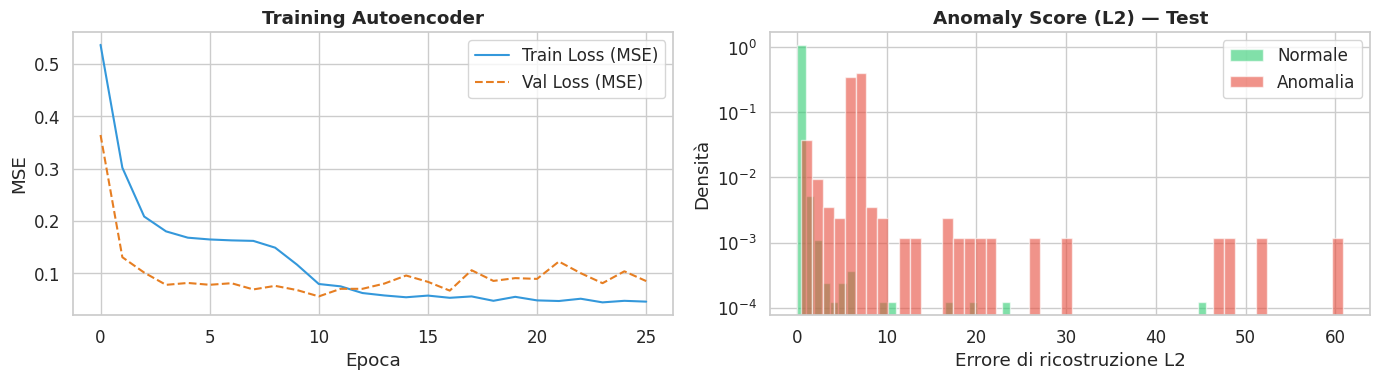

AUC-ROC del solo Autoencoder: 0.9989


In [8]:
def reconstruction_l2(tensor):
    model.eval()
    with torch.no_grad():
        recon = model(tensor)
        return torch.sqrt(torch.sum((tensor - recon) ** 2, dim=1)).numpy()

ae_score_val  = reconstruction_l2(val_tensor)
ae_score_test = reconstruction_l2(test_tensor)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_hist, label="Train Loss (MSE)", color="#3498db")
axes[0].plot(val_hist, label="Val Loss (MSE)", color="#e67e22", linestyle="--")
axes[0].set_title("Training Autoencoder", fontweight="bold")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("MSE"); axes[0].legend()

for lab, col, name in [(0, "#2ecc71", "Normale"), (1, "#e74c3c", "Anomalia")]:
    axes[1].hist(ae_score_test[y_test.values == lab], bins=50, alpha=0.6,
                 color=col, density=True, label=name)
axes[1].set_title("Anomaly Score (L2) — Test", fontweight="bold")
axes[1].set_xlabel("Errore di ricostruzione L2"); axes[1].set_ylabel("Densità")
axes[1].legend(); axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("fig_sh_autoencoder.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"AUC-ROC del solo Autoencoder: {roc_auc_score(y_test, ae_score_test):.4f}")


## 6. Modello 2 — Random Forest (Bagging, Sez. 15)

Molti alberi de-correlati (bootstrap sulle righe + `max_features="sqrt"`); mediando alberi ad alta
varianza, gli errori idiosincratici si cancellano. `class_weight="balanced"` compensa lo
sbilanciamento.

AUC-ROC Random Forest: 1.0000


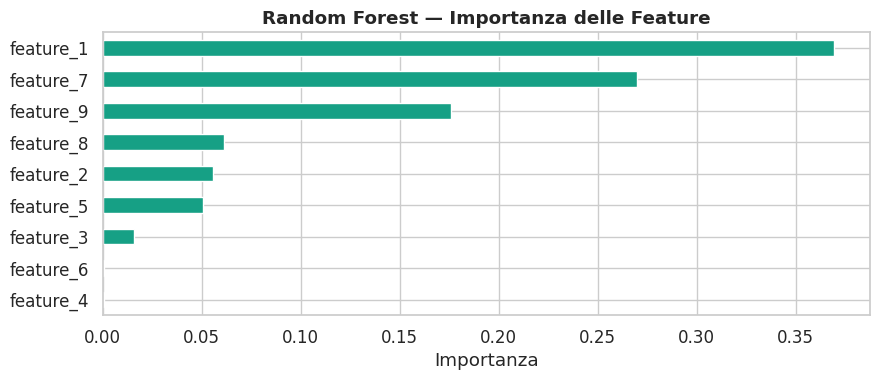

In [9]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, max_features="sqrt",
    class_weight="balanced", random_state=SEED, n_jobs=-1
)
rf.fit(X_train_sc, y_train)
rf_score_val  = rf.predict_proba(X_val_sc)[:, 1]
rf_score_test = rf.predict_proba(X_test_sc)[:, 1]
print(f"AUC-ROC Random Forest: {roc_auc_score(y_test, rf_score_test):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
pd.Series(rf.feature_importances_, index=feature_cols).sort_values().plot(
    kind="barh", color="#16a085", ax=ax)
ax.set_title("Random Forest — Importanza delle Feature", fontweight="bold")
ax.set_xlabel("Importanza")
plt.tight_layout()
plt.savefig("fig_sh_rf_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Modello 3 — XGBoost (Boosting, Sez. 16)

Alberi costruiti in sequenza: ogni nuovo albero corregge gli errori residui del precedente (riduce
il bias). Parametri chiave (Sez. 16): `learning_rate` piccolo, `max_depth` basso (alberi deboli),
`reg_lambda` (L2), early stopping su validation. `scale_pos_weight` compensa lo sbilanciamento.

In [10]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=600, learning_rate=0.05, max_depth=5,
    reg_lambda=1.0, subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric="logloss",
    early_stopping_rounds=20, random_state=SEED, n_jobs=-1
)
xgb.fit(X_train_sc, y_train, eval_set=[(X_val_sc, y_val)], verbose=False)
print(f"Boosting fermato a {xgb.best_iteration + 1} alberi (early stopping).")

xgb_score_val  = xgb.predict_proba(X_val_sc)[:, 1]
xgb_score_test = xgb.predict_proba(X_test_sc)[:, 1]
print(f"AUC-ROC XGBoost: {roc_auc_score(y_test, xgb_score_test):.4f}")


Boosting fermato a 360 alberi (early stopping).
AUC-ROC XGBoost: 1.0000


## 8. Ensemble dei Segnali + Soglia Ottimizzata (Sez. 14)

I tre score hanno scale diverse (L2 vs probabilità): si normalizzano in [0,1] con parametri appresi
**solo sul validation** (no leakage sul test), poi si mediano. La **soglia** che converte lo score
in classe è cercata massimizzando l'F1 sul validation (Sez. 14), mai sul test.

In [11]:
def mm_fit(s):   return s.min(), s.max()
def mm_apply(s, lo, hi): return np.clip((s - lo) / (hi - lo + 1e-12), 0, 1)

ae_lo,  ae_hi  = mm_fit(ae_score_val)
rf_lo,  rf_hi  = mm_fit(rf_score_val)
xgb_lo, xgb_hi = mm_fit(xgb_score_val)

def ensemble_score(ae, rf_, xgb_):
    return (mm_apply(ae, ae_lo, ae_hi)
          + mm_apply(rf_, rf_lo, rf_hi)
          + mm_apply(xgb_, xgb_lo, xgb_hi)) / 3.0

ens_val  = ensemble_score(ae_score_val,  rf_score_val,  xgb_score_val)
ens_test = ensemble_score(ae_score_test, rf_score_test, xgb_score_test)

thr_grid = np.linspace(ens_val.min(), ens_val.max(), 500)
f1_val   = [f1_score(y_val, (ens_val > t).astype(int), zero_division=0) for t in thr_grid]
THRESHOLD = thr_grid[int(np.argmax(f1_val))]
print(f"Soglia ottimale (max F1 su validation): {THRESHOLD:.4f}")
print(f"F1 sul validation a quella soglia: {max(f1_val):.4f}")


Soglia ottimale (max F1 su validation): 0.2482
F1 sul validation a quella soglia: 1.0000


## 9. Valutazione Comparativa sul Test Set

Confronto equo: per ogni modello la soglia è ottimizzata in F1 sul validation, poi applicata al
test. Metriche corrette per classi sbilanciate (Sez. 13).

In [12]:
def best_threshold(sv, yv):
    grid = np.linspace(sv.min(), sv.max(), 500)
    f1s  = [f1_score(yv, (sv > t).astype(int), zero_division=0) for t in grid]
    return grid[int(np.argmax(f1s))]

def evaluate(name, sv, st, yv, yt):
    t = best_threshold(sv, yv)
    pred = (st > t).astype(int)
    return {"Modello": name,
            "Precision": precision_score(yt, pred, zero_division=0),
            "Recall":    recall_score(yt, pred, zero_division=0),
            "F1":        f1_score(yt, pred, zero_division=0),
            "AUC-ROC":   roc_auc_score(yt, st)}

results = [
    evaluate("Autoencoder (solo)",   ae_score_val,  ae_score_test,  y_val, y_test),
    evaluate("Random Forest",        rf_score_val,  rf_score_test,  y_val, y_test),
    evaluate("XGBoost",              xgb_score_val, xgb_score_test, y_val, y_test),
    evaluate("ENSEMBLE (AE+RF+XGB)", ens_val,       ens_test,       y_val, y_test),
]
res_df = pd.DataFrame(results).set_index("Modello").round(4)
display(res_df)


,Precision,Recall,F1,AUC-ROC
Modello,,,,
Autoencoder (solo),0.9640,0.9544,0.9592,0.9989
Random Forest,1.0000,1.0000,1.0000,1.0000
XGBoost,0.9986,1.0000,0.9993,1.0000
ENSEMBLE (AE+RF+XGB),1.0000,1.0000,1.0000,1.0000


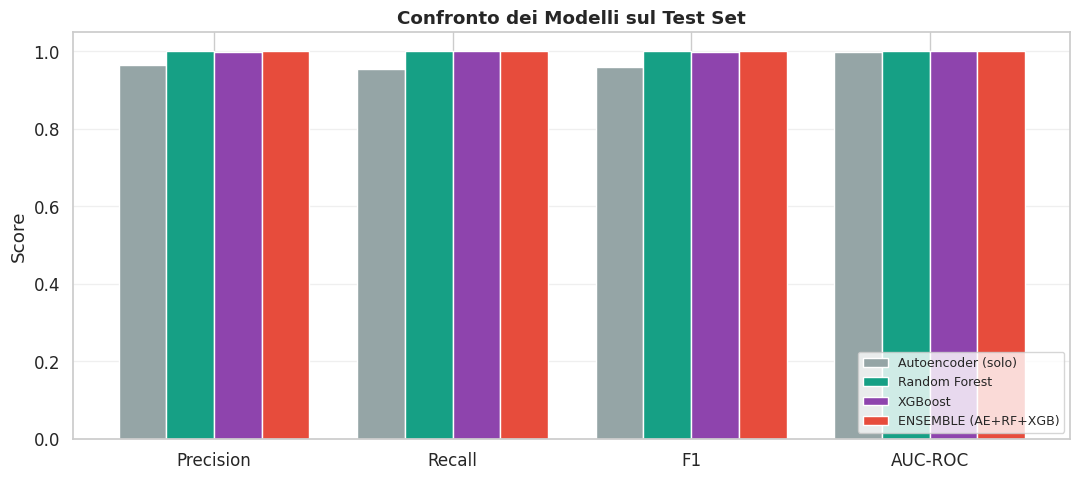

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics_plot = ["Precision", "Recall", "F1", "AUC-ROC"]
x = np.arange(len(metrics_plot)); width = 0.2
colors = ["#95a5a6", "#16a085", "#8e44ad", "#e74c3c"]
for i, (name, row) in enumerate(res_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics_plot], width,
           label=name, color=colors[i], edgecolor="white")
ax.set_xticks(x + 1.5 * width); ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Confronto dei Modelli sul Test Set", fontweight="bold")
ax.legend(fontsize=9, loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_sh_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


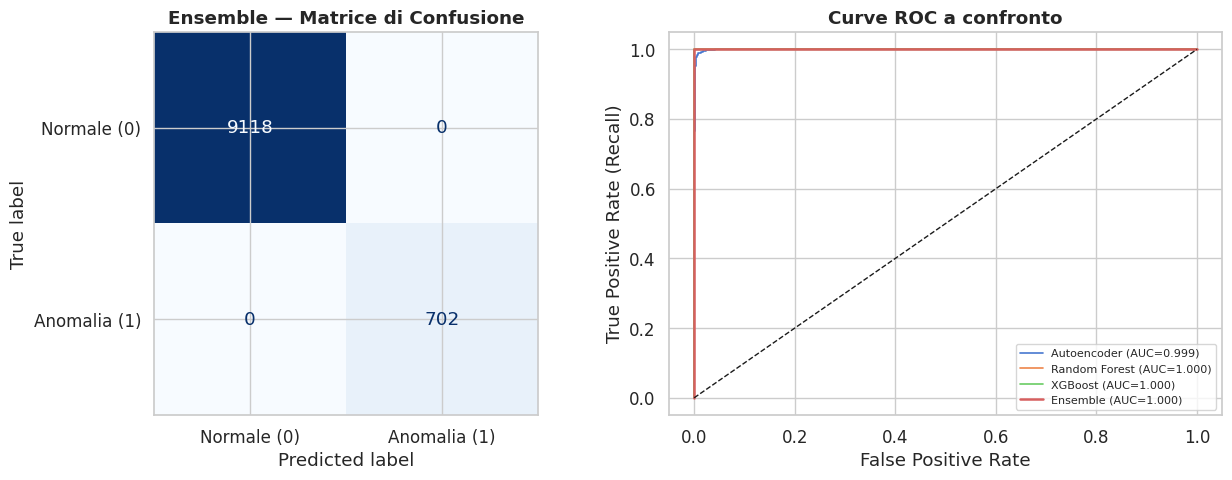

TN=9118  FP=0  FN=0  TP=702


In [14]:
y_pred_ens = (ens_test > THRESHOLD).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_ens)
ConfusionMatrixDisplay(cm, display_labels=["Normale (0)", "Anomalia (1)"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Ensemble — Matrice di Confusione", fontweight="bold")

for name, sc in [("Autoencoder", ae_score_test), ("Random Forest", rf_score_test),
                 ("XGBoost", xgb_score_test), ("Ensemble", ens_test)]:
    fpr, tpr, _ = roc_curve(y_test, sc)
    axes[1].plot(fpr, tpr, linewidth=1.8 if name == "Ensemble" else 1.2,
                 label=f"{name} (AUC={roc_auc_score(y_test, sc):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("Curve ROC a confronto", fontweight="bold")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("fig_sh_confusion_roc.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")


## 10. Visualizzazione dello Spazio Latente (PCA, Sez. 19–20)

Lo spazio latente (dim=3) viene proiettato in 2D con **PCA** (deterministica, proietta nuovi punti,
adatta a preprocessing e visualizzazione — Sez. 20). Si usa PCA e non t-SNE perché t-SNE è solo
per visualizzazione esplorativa e non trasforma nuovi punti.

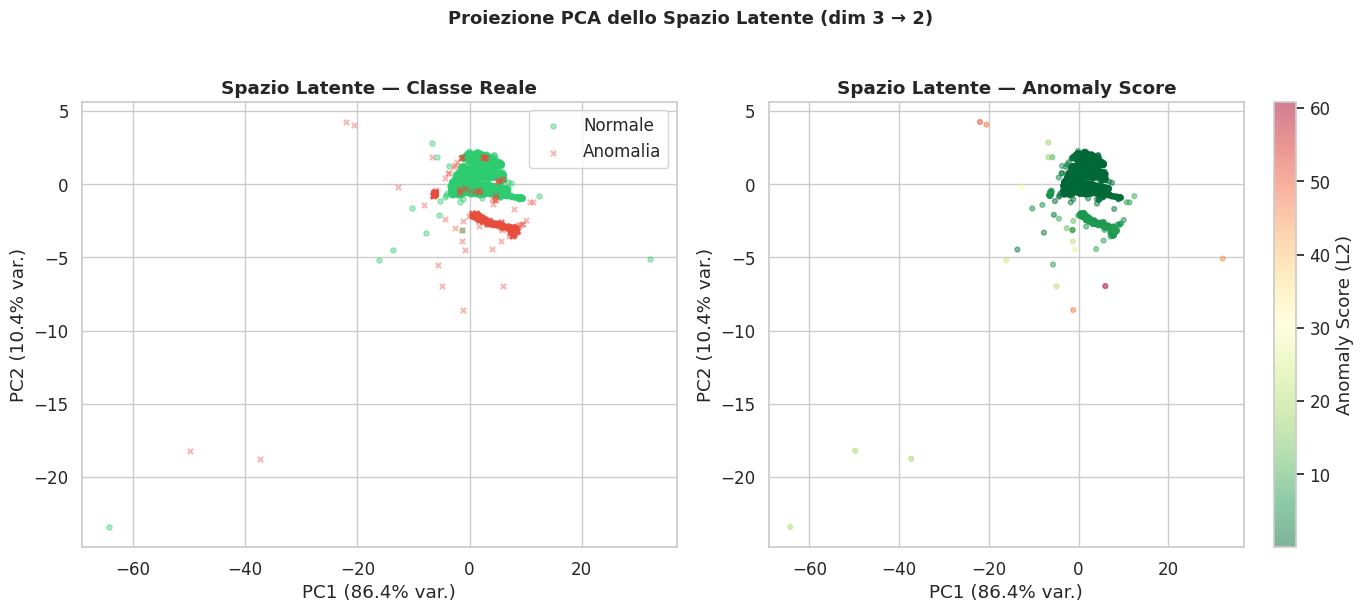

Varianza spiegata da PC1+PC2: 96.8%


In [15]:
model.eval()
with torch.no_grad():
    latent_test = model.encode(test_tensor).numpy()

pca = PCA(n_components=2, random_state=SEED)
latent_2d = pca.fit_transform(latent_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for lab, col, mk, name in [(0, "#2ecc71", "o", "Normale"), (1, "#e74c3c", "x", "Anomalia")]:
    m = y_test.values == lab
    axes[0].scatter(latent_2d[m, 0], latent_2d[m, 1], c=col, marker=mk,
                    alpha=0.4, s=14, label=name)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
axes[0].set_title("Spazio Latente — Classe Reale", fontweight="bold"); axes[0].legend()

sc = axes[1].scatter(latent_2d[:, 0], latent_2d[:, 1], c=ae_score_test,
                     cmap="RdYlGn_r", alpha=0.5, s=12)
plt.colorbar(sc, ax=axes[1], label="Anomaly Score (L2)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
axes[1].set_title("Spazio Latente — Anomaly Score", fontweight="bold")
plt.suptitle("Proiezione PCA dello Spazio Latente (dim 3 → 2)", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_sh_latent.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Varianza spiegata da PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")


## 11. Riepilogo Finale

In [16]:
print("=" * 66)
print("   RIEPILOGO — ANOMALY DETECTION SU STATLOG (SHUTTLE)")
print("=" * 66)
print(f"\nDataset : {len(df)} campioni, {len(feature_cols)} feature numeriche")
print(f"          {df['anomaly'].sum()} anomalie ({df['anomaly'].mean()*100:.1f}%)")
print("\nMetodo  : ensemble di tre anomaly score normalizzati e mediati")
print("  1. Autoencoder denso (Sez. 21-22) — errore di ricostruzione L2,")
print("     addestrato SOLO sui normali, anti-leakage (Sez. 11)")
print("  2. Random Forest (Sez. 15) — bagging, riduce la varianza")
print("  3. XGBoost (Sez. 16) — boosting, riduce il bias, early stopping")
print("  + Standardizzazione necessaria per la rete neurale (Sez. 9)")
print("  + Soglia ottimizzata in F1 sul VALIDATION set (Sez. 14)")
print("  + Metriche per classi sbilanciate (Sez. 13)")
print("  + Visualizzazione latente con PCA (Sez. 19-20)")
print("\n" + "-" * 66)
print("Risultati sul test set:")
print("-" * 66)
print(res_df.to_string())
print("-" * 66)
b = res_df.loc["ENSEMBLE (AE+RF+XGB)"]
print(f"\nEnsemble finale -> Precision={b['Precision']:.3f}  "
      f"Recall={b['Recall']:.3f}  F1={b['F1']:.3f}  AUC={b['AUC-ROC']:.3f}")
print("=" * 66)


   RIEPILOGO — ANOMALY DETECTION SU STATLOG (SHUTTLE)

Dataset : 49097 campioni, 9 feature numeriche
          3511 anomalie (7.2%)

Metodo  : ensemble di tre anomaly score normalizzati e mediati
  1. Autoencoder denso (Sez. 21-22) — errore di ricostruzione L2,
     addestrato SOLO sui normali, anti-leakage (Sez. 11)
  2. Random Forest (Sez. 15) — bagging, riduce la varianza
  3. XGBoost (Sez. 16) — boosting, riduce il bias, early stopping
  + Standardizzazione necessaria per la rete neurale (Sez. 9)
  + Soglia ottimizzata in F1 sul VALIDATION set (Sez. 14)
  + Metriche per classi sbilanciate (Sez. 13)
  + Visualizzazione latente con PCA (Sez. 19-20)

------------------------------------------------------------------
Risultati sul test set:
------------------------------------------------------------------
                      Precision  Recall      F1  AUC-ROC
Modello                                                 
Autoencoder (solo)       0.9640  0.9544  0.9592   0.9989
Random Fore